# SQLite:
- It's a database that lives inside the `.db` file
- No server, No password, Python has it built-in -> zero installation.


In [47]:
import sqlite3

def get_connection():
    connection = sqlite3.connect("Database/incidents.db")
    connection.row_factory = sqlite3.Row
    return connection

if __name__ == "__main__":
    connection = get_connection()
    print(type(connection))
    print("connection successful")
    connection.close()

<class 'sqlite3.Connection'>
connection successful


### Learnings from above Code:
##### 1. what is connection? why we need to connect to database?  

```py 
connection = sqlite3.connect("Database/incidents.db")
```
- connection isn't just a variable; it’s a "pipe" ***held open*** between your ***script*** and the ***database server***.
- It helps performing crud operations to database.

##### 2. What `conn.row_factory = sqlite3.Row` does?

 ```py 
 connection.row_factory = sqlite3.Row
 ```

- Without *row_factory*, when you fetch data from DB, Python gives you back *plain tuples*:
    ```py
    (1, "helmet missing", "zone-A")
    ```
    You access data like row[0], row[1] — by index. Fragile and unreadable.


- With `row_factory = sqlite3.Row`, Python gives you back *dict-like objects*:
    ```py
    row["id"], row["description"], row["zone"]
    ```
    You access by column name. Much safer, much more readable. This is what you'll always want in production.

##### 3. Resource Leaks (The "Memory" Part)

- **The Leak**: Every time you call `get_connection()`, the operating system sets aside a small chunk of RAM to manage that pipe. If you forget to call `.close()`, that memory stays "reserved" even if your script is done using it.

- **The Crash**: If this happens inside a loop (like a website handling thousands of visitors), those tiny chunks of RAM add up. Eventually, the server runs out of memory and the program crashes because it has nowhere left to store data

##### 4. File Locks
*To ensure data doesn't get corrupted, databases often use File Locks. Think of this like a "Do Not Disturb" sign on a hotel room door.*

- **The Logic:** When a program connects to a database file, it might "lock" that file so that two programs don't try to write to the exact same spot at the exact same millisecond (which would scramble the data).

- **The Problem:** If your program opens a connection, triggers a lock, and then "hangs" or finishes without calling `.close()`, that lock might stay active.

- **The Consequence**: The next time you (or another user) try to access the database, the system says, "Sorry, this file is currently in use/locked," and denies access.

# PART 2: CREATE TABLE:

In [48]:
import sqlite3

def get_connection():
    conn = sqlite3.connect("Database/incidents.db")
    conn.row_factory = sqlite3.Row
    return conn

def create_table(conn):
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS incidents (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            title       TEXT NOT NULL,
            zone        TEXT NOT NULL,
            severity    TEXT CHECK(severity IN ('low', 'medium', 'high')) NOT NULL,
            created_at  TEXT DEFAULT (datetime('now'))
        )
        """)
    conn.commit()
    print("table created")
    
def update_table(conn):
    ...

if __name__ == "__main__":
    conn = get_connection()
    create_table(conn)
    conn.close()

table created


### Learnings

##### 1. cursor
- `conn` gives you a connection, but `cursor` is the thing `that actually executes SQL`. 
- Think of conn as the door to the DB, and cursor as your hands inside it.

##### 2. commit(): 
*what is the use-case of it, we'll see in next section*

### what is commit():
- commit() saves the data into the database.

Here there are 2 codes, in both codes we are not using commit().

- In first code, we are inserting data into the DB, then retrieving it, then closing the connection.
- Now second code depicts, once we close the connection without commit(), we lost our data i.e. data is not saved into DB.

In [49]:
import sqlite3

conn = sqlite3.connect("Database/incidents.db")
conn.row_factory = sqlite3.Row

cursor = conn.cursor()

cursor.execute("INSERT INTO incidents (title, zone, severity) VALUES (?, ?, ?)",
               ("test incident", "zone-A", "high"))

cursor.execute("SELECT * FROM incidents")
rows = cursor.fetchall()

print(f"{type(rows) = }")
print(f"{rows = }")

for row in rows:
    print(dict(row))

conn.close()

type(rows) = <class 'list'>
rows = [<sqlite3.Row object at 0x000001E272E81C30>]
{'id': 1, 'title': 'test incident', 'zone': 'zone-A', 'severity': 'high', 'created_at': '2026-03-17 20:46:58'}


In [50]:
import sqlite3

conn = sqlite3.connect("Database/incidents.db")
conn.row_factory = sqlite3.Row

cursor = conn.cursor()

cursor.execute("SELECT * FROM incidents")
rows = cursor.fetchall()

print("rows found:", len(rows))
for row in rows:
    print(dict(row))

conn.close()

rows found: 0


#### Conclusion: 
Even in the first code we inserted the values but still we are not getting them into second code, Reason: we did not commit(). so inserted data is lost in once connection is closed.

# PART 3 : INSERTING DATA INTO TABLE

In [51]:
import sqlite3

def get_connection():
    conn = sqlite3.connect("Database/incidents.db")
    conn.row_factory = sqlite3.Row
    return conn

def create_table(conn):
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS incidents (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            title       TEXT NOT NULL,
            zone        TEXT NOT NULL,
            severity    TEXT CHECK(severity IN ('low', 'medium', 'high')) NOT NULL,
            created_at  TEXT DEFAULT (datetime('now'))
        )
        """)
    conn.commit()
    print("table created")

def add_incident(conn, title, zone, severity):
    cursor = conn.cursor()
    cursor.execute("""
    INSERT INTO incidents (title, zone, severity) VALUES (?, ?, ?)""", (title, zone, severity))
    conn.commit()
    print(f"incident saved with id = {cursor.lastrowid}")
    return cursor.lastrowid


if __name__ == "__main__":
    conn = get_connection()
    create_table(conn)
    
    add_incident(conn, "Worker without helmet", "Zone-A", "high")
    add_incident(conn, "Spill near conveyor", "Zone-B", "medium")
    add_incident(conn, "Fire exit blocked", "Zone-C", "low")

    conn.close()


table created
incident saved with id = 1
incident saved with id = 2
incident saved with id = 3


***NOTE**: If we run the above code again, then duplicate rows will be inserted into database*

In [52]:
# Print the values

import sqlite3

conn = sqlite3.connect("Database/incidents.db")
conn.row_factory = sqlite3.Row
cursor = conn.cursor()

cursor.execute("SELECT * FROM incidents")
rows = cursor.fetchall()

print("rows found:", len(rows))
for row in rows:
    print(dict(row))

conn.close()


rows found: 3
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': '2026-03-17 20:47:04'}
{'id': 2, 'title': 'Spill near conveyor', 'zone': 'Zone-B', 'severity': 'medium', 'created_at': '2026-03-17 20:47:04'}
{'id': 3, 'title': 'Fire exit blocked', 'zone': 'Zone-C', 'severity': 'low', 'created_at': '2026-03-17 20:47:04'}


#### Two things to notice:

1. See those `?` placeholders — why do you think we use `?` instead of just formatting the string directly like `f"INSERT ... VALUES ('{title}'...)"` ?

2. `cursor.lastrowid` — what do you think this gives you?


### Why we should use `?` and not f-string:
**REASON : SQL - injection**

Let's understand SQL-injection from example below:  
   ```python
    title = input("enter title: ")
    cursor.execute(f"INSERT INTO incidents (title) VALUES ('{title}')")
   ```

And suppose a malicious user types this as the title:

`'); DROP TABLE incidents; --`

then above query becomes:
   ```sql
    INSERT INTO incidents (title) VALUES (''); DROP TABLE incidents; --')
   ```

Let's look it closely:
- Malicious user's input = `'); DROP TABLE incidents; --`
- see starting input `');` <- this completes the existing query, then following this, the malicious user *appending new query* inside *title* itself see `DROP TABLE incidents;` and rest part is being converted into *comments* as followed by `--`

So this would delete whole data. BAM

#### CONCLUSION:
When you use `?`, SQLite treats the value as `pure data`, `never as SQL code`. The`?` is not just a placeholder — it's a security boundary. 

# PART 4: fetchall() vs fetchone() vs fetchmany():

In [53]:
import sqlite3

def get_connection():
    conn = sqlite3.connect("Database/incidents.db")
    conn.row_factory = sqlite3.Row
    return conn

def get_all_incidents(conn):
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM incidents ORDER BY created_at DESC")
    rows = cursor.fetchall()
    return rows

def get_incident_by_id(conn, incident_id):
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM incidents WHERE id = ?", (incident_id,))
    row = cursor.fetchone()
    return row


if __name__ == "__main__":
    conn = get_connection()

    all_incidents = get_all_incidents(conn)
    print(f"total incidents: {len(all_incidents)}")
    print("--- all incidents ---")
    for row in all_incidents:
        print(dict(row))

    print("\n--- single incident ---")
    one = get_incident_by_id(conn, 1)
    print(dict(one))

    print("\n--- what if id doesnt exist ---")
    missing = get_incident_by_id(conn, 9999)
    print(missing)

    conn.close()

total incidents: 3
--- all incidents ---
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': '2026-03-17 20:47:04'}
{'id': 2, 'title': 'Spill near conveyor', 'zone': 'Zone-B', 'severity': 'medium', 'created_at': '2026-03-17 20:47:04'}
{'id': 3, 'title': 'Fire exit blocked', 'zone': 'Zone-C', 'severity': 'low', 'created_at': '2026-03-17 20:47:04'}

--- single incident ---
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': '2026-03-17 20:47:04'}

--- what if id doesnt exist ---
None


### LEARNINGS:

**1. what does Python return when a row doesn't exist?**  
  ANSWER : it returns `None`

**2. Why do you think we write `(incident_id,)` with a trailing comma instead of just `(incident_id)` in `get_incident_by_id` function?**  
 **ANSWER**:   
  when we write query with `?` inside the sql query, then value of variables passed should be inside the `tuple`.  
  So when we do this:
   ```py
    x = (incident_id)   # this is just an integer in brackets. NOT a tuple.
    x = (incident_id,)  # this IS a tuple with one element.
   ```
  SQLite expects a `tuple` when you pass `parameters`. When you wrote `(incident_id) without the comma`, you handed it a `plain integer`. SQLite got confused — it expected something iterable, got a number, and crashed.

#### fetchmany():
- fetches rows in chunks — you process one chunk, then fetch the next. Memory stays controlled.

- **why it exists?**  
Imagine a factory with 200 cameras running 24/7. Your incidents table has 500,000 rows.
   ```py
    rows = cursor.fetchall()  # loads ALL 500,000 rows into RAM at once
   ```
   *Your server runs out of memory and crashes. This is a real production problem.*

In [54]:
def get_incidents_in_chunks(conn, chunk_size=2):
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM incidents ORDER BY created_at DESC")

    while True:
        rows = cursor.fetchmany(chunk_size)
        if not rows:
            break
        print(f"--- processing chunk of {len(rows)} rows ---")
        for row in rows:
            print(dict(row))
            

if __name__ == "__main__":
    conn = get_connection()
    get_incidents_in_chunks(conn)
    conn.close()

--- processing chunk of 2 rows ---
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': '2026-03-17 20:47:04'}
{'id': 2, 'title': 'Spill near conveyor', 'zone': 'Zone-B', 'severity': 'medium', 'created_at': '2026-03-17 20:47:04'}
--- processing chunk of 1 rows ---
{'id': 3, 'title': 'Fire exit blocked', 'zone': 'Zone-C', 'severity': 'low', 'created_at': '2026-03-17 20:47:04'}


**Notice:**

- It processes 2 rows at a time, not everything at once
- When no rows are left, fetchmany() returns an empty list [] — that's what breaks the loop

## PART 5: Update and Delete

In [55]:
import sqlite3

def get_connection():
    conn = sqlite3.connect("Database/incidents.db")
    conn.row_factory = sqlite3.Row
    return conn


def get_all_incidents(conn):
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM incidents ORDER BY created_at DESC")
    rows = cursor.fetchall()
    return rows

def get_incident_by_id(conn, incident_id):
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM incidents WHERE id = ?", (incident_id,))
    row = cursor.fetchone()
    return row


def update_severity(conn, incident_id, new_severity):
    cursor = conn.cursor()

    cursor.execute("""UPDATE incidents SET severity = ? where id = ?""",(new_severity, incident_id))
    conn.commit()
    print(f"rows affected: {cursor.rowcount}")

    return cursor.rowcount


def delete_incident(conn, incident_id):
    cursor = conn.cursor()

    cursor.execute("""DELETE FROM incidents where id = ?""",(incident_id,))
    conn.commit()
    print(f"rows deleted: {cursor.rowcount}")
    return cursor.rowcount


if __name__ == "__main__":
    conn = get_connection()

    print("--- before update ---")
    print(dict(get_incident_by_id(conn, 1)))

    update_severity(conn, 1, "low")

    print("\n--- after update ---")
    print(dict(get_incident_by_id(conn, 1)))

    print("\n--- deleting incident 2 ---")
    delete_incident(conn, 2)

    print("\n--- all incidents now ---")
    for row in get_all_incidents(conn):
        print(dict(row))

    print("\n--- update non existent row ---")
    affected = update_severity(conn, 9999, "high")
    print(f"affected: {affected}")

    conn.close()


--- before update ---
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': '2026-03-17 20:47:04'}
rows affected: 1

--- after update ---
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'low', 'created_at': '2026-03-17 20:47:04'}

--- deleting incident 2 ---
rows deleted: 1

--- all incidents now ---
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'low', 'created_at': '2026-03-17 20:47:04'}
{'id': 3, 'title': 'Fire exit blocked', 'zone': 'Zone-C', 'severity': 'low', 'created_at': '2026-03-17 20:47:04'}

--- update non existent row ---
rows affected: 0
affected: 0


# summary of what you've learned so far:

- Connect to SQLite, what a Connection object is
- What row_factory does and why
- cursor — the thing that actually runs SQL or executes the queries. You can have `multiple cursors` on `one connection` running different queries simultaneously.
- Transactions — commit() and why without it changes vanish
- SQL injection and why ? placeholders are non-negotiable
-fetchone, fetchall, fetchmany — when to use which
- lastrowid — get the ID of what you just inserted
-rowcount — know if your update/delete actually did anything
- **None** guard — always check before using a result.  
   - below is example of None guard:
   ```py
   if one is None:
      print("incident not found")
   else:
      print(dict(one))
   ```

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

## POSTGRES WITH PYTHON:

#####  1. Driver:
- A driver is a translator. 
- It sits between your `Python code` and the `database`.
- converts Python instructions into something the database understands, and converting database responses back into Python objects.

    ```bash
    Your Python code
        ↓
    Driver          ← this is the translator
        ↓
    Database

    ```

- Without a driver, Python has no idea how to speak "SQLite language" or "PostgreSQL language". 

- **What is sqlite3 then?**
  - sqlite3 is the official built-in Python driver for SQLite. 
  - When you wrote import sqlite3 — you imported the translator that knows how to speak to a SQLite .db file. That's it.
  - similarly `psycopg2` is also driver


    | Database                  | Python Driver                                      |
    |--------------------------|---------------------------------------------------|
    | SQLite                   | sqlite3 — built into Python, no install needed    |
    | PostgreSQL               | psycopg2 — you install it                         |
    | MySQL                    | mysql-connector — you install it                  |
    | SQLite / Postgres / MySQL| SQLAlchemy — works with all of them, we'll get here |        


---

#### what do you think `will change` and `what will stay the same` when we switch from `sqlite3` to `psycopg2`?
 - **What changes:**
   - The driver — `sqlite3` to `psycopg2`
   - The connection call — instead of a filename, you pass `host`, `port`, `username`, `password`, `database name`.
   - The placeholder — SQLite uses `?`, PostgreSQL uses `%s`.

 - **What stays exactly the same:**
   - `conn`, `cursor` — same mental model
   - `cursor.execute()` — same
   - `fetchone`, `fetchall`, `fetchmany` — same
   - `commit()`, `rollback()` — same
   - `cursor.rowcount`, `cursor.lastrowid` — same


---

## Connect postgres database in python code:

To connect postgres database from python code, we need 5 things:
 - user
 - password
 - host
 - port
 - database name

Driver need = **psycopg2**

Let's see how to connect

In [57]:
import psycopg2

def get_connection():
    conn = psycopg2.connect(
        host = "localhost",
        user = "postgres",
        database="hawkvision_dev",
        password="123",
        port=5432,
    )
    return conn

if __name__=="__main__":
    conn = get_connection()
    print(type(conn))
    print("connection successful")
    conn.close()


<class 'psycopg2.extensions.connection'>
connection successful


## BEST PRACTICE! 
***In production environment, we never put credentials hard-coded.***  

**The production way — environment variables**   
passwords should live inside the .env file or environment.
1. **STEP 1** : install `python-dotenv` [*pip install python-dotenv*]
2. **STEP 2**: create a `.env` file in your project folder, and variables inside that.
   ```bash
    DB_HOST=localhost
    DB_PORT=5432
    DB_NAME=hawkvision_dev
    DB_USER=postgres
    DB_PASSWORD=your_actual_password
   ```
3. **STEP 3** : create a `config.py` file:
    ```python
    from dotenv import load_dotenv
    import os

    load_dotenv()

    DB_HOST     = os.getenv("DB_HOST")
    DB_PORT     = os.getenv("DB_PORT")
    DB_NAME     = os.getenv("DB_NAME")
    DB_USER     = os.getenv("DB_USER")
    DB_PASSWORD = os.getenv("DB_PASSWORD")

    ```
* .env file          → stores secrets (never pushed to git)
* config.py          → reads from .env, exposes as Python variables.   

*Now you can import these variables in any other file and use them.*

Let's create a .env file and a config file then we'll be importing those variables here in this notebook.

In [ ]:
import psycopg2
from config import DB_HOST, DB_NAME, DB_PASSWORD, DB_PORT, DB_USER
from psycopg2.extras import RealDictCursor

def get_connection():
    conn = psycopg2.connect(
        host = DB_HOST,
        port = DB_PORT,
        database = DB_NAME,
        user = DB_USER,
        password = DB_PASSWORD
    )
    return conn

def create_tables(conn):
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute(""" 
        CREATE TABLE IF NOT EXISTS incidents (
        id          SERIAL PRIMARY KEY,
        title       TEXT NOT NULL,
        zone        TEXT NOT NULL,
        severity    TEXT CHECK(severity IN ('low', 'medium', 'high')) NOT NULL,
        created_at  TIMESTAMP DEFAULT NOW())
    """)
    conn.commit()
    print("table created    ")


def add_incident(conn, title, zone, severity):
    cursor = conn.cursor(cursor_factory=RealDictCursor)

    cursor.execute("""
        INSERT INTO incidents (title, zone, severity)
        VALUES (%s, %s, %s)
        RETURNING id, title, zone, severity, created_at
    """, (title, zone, severity))

    conn.commit()
    row = cursor.fetchone()
    print(f"incident saved: {dict(row)}")  
    return dict(row)


def get_all_incidents(conn):
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute("SELECT * FROM incidents ORDER BY created_at DESC")
    rows = cursor.fetchall()
    return [dict(row) for row in rows] # converting each row to 'dict' because currently these are RealDictCursor objects.


def get_incident_by_id(conn, incident_id):
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute("SELECT * FROM incidents WHERE id = %s", (incident_id,))
    row = cursor.fetchone()
    return dict(row) if row else None    # Again converting to dict


def update_severity(conn, incident_id, new_severity):
    cursor = conn.cursor(cursor_factory=RealDictCursor)

    cursor.execute("""
        UPDATE incidents
        SET severity = %s
        WHERE id = %s
        RETURNING id, title, severity
    """, (new_severity, incident_id))

    conn.commit()
    row = cursor.fetchone()
    return dict(row) if row else None


def delete_incident(conn, incident_id):
    cursor = conn.cursor(cursor_factory=RealDictCursor)
    cursor.execute(
        "DELETE FROM incidents WHERE id = %s RETURNING id",
        (incident_id,)
    )
    conn.commit()
    row = cursor.fetchone()
    return dict(row) if row else None


if __name__ == "__main__":
    conn = get_connection()
    create_tables(conn)

    # insert
    add_incident(conn, "Worker without helmet", "Zone-A", "high")
    add_incident(conn, "Spill near conveyor", "Zone-B", "medium")
    add_incident(conn, "Fire exit blocked", "Zone-C", "low")

    # read all
    print("\n--- all incidents ---")
    for inc in get_all_incidents(conn):
        print(inc)

    # read one
    print("\n--- incident 1 ---")
    print(get_incident_by_id(conn, 1))

    # update
    print("\n--- updating incident 1 ---")
    print(update_severity(conn, 1, "low"))

    # delete
    print("\n--- deleting incident 2 ---")
    print(delete_incident(conn, 2))

    # missing
    print("\n--- missing row ---")
    print(get_incident_by_id(conn, 9999))

    conn.close()

table created    
incident saved: {'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 928642)}
incident saved: {'id': 2, 'title': 'Spill near conveyor', 'zone': 'Zone-B', 'severity': 'medium', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 935381)}
incident saved: {'id': 3, 'title': 'Fire exit blocked', 'zone': 'Zone-C', 'severity': 'low', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 935876)}

--- all incidents ---
{'id': 3, 'title': 'Fire exit blocked', 'zone': 'Zone-C', 'severity': 'low', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 935876)}
{'id': 2, 'title': 'Spill near conveyor', 'zone': 'Zone-B', 'severity': 'medium', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 935381)}
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 928642)}

--- incident 1 ---
{'id': 1, 'ti

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# Connection pooling

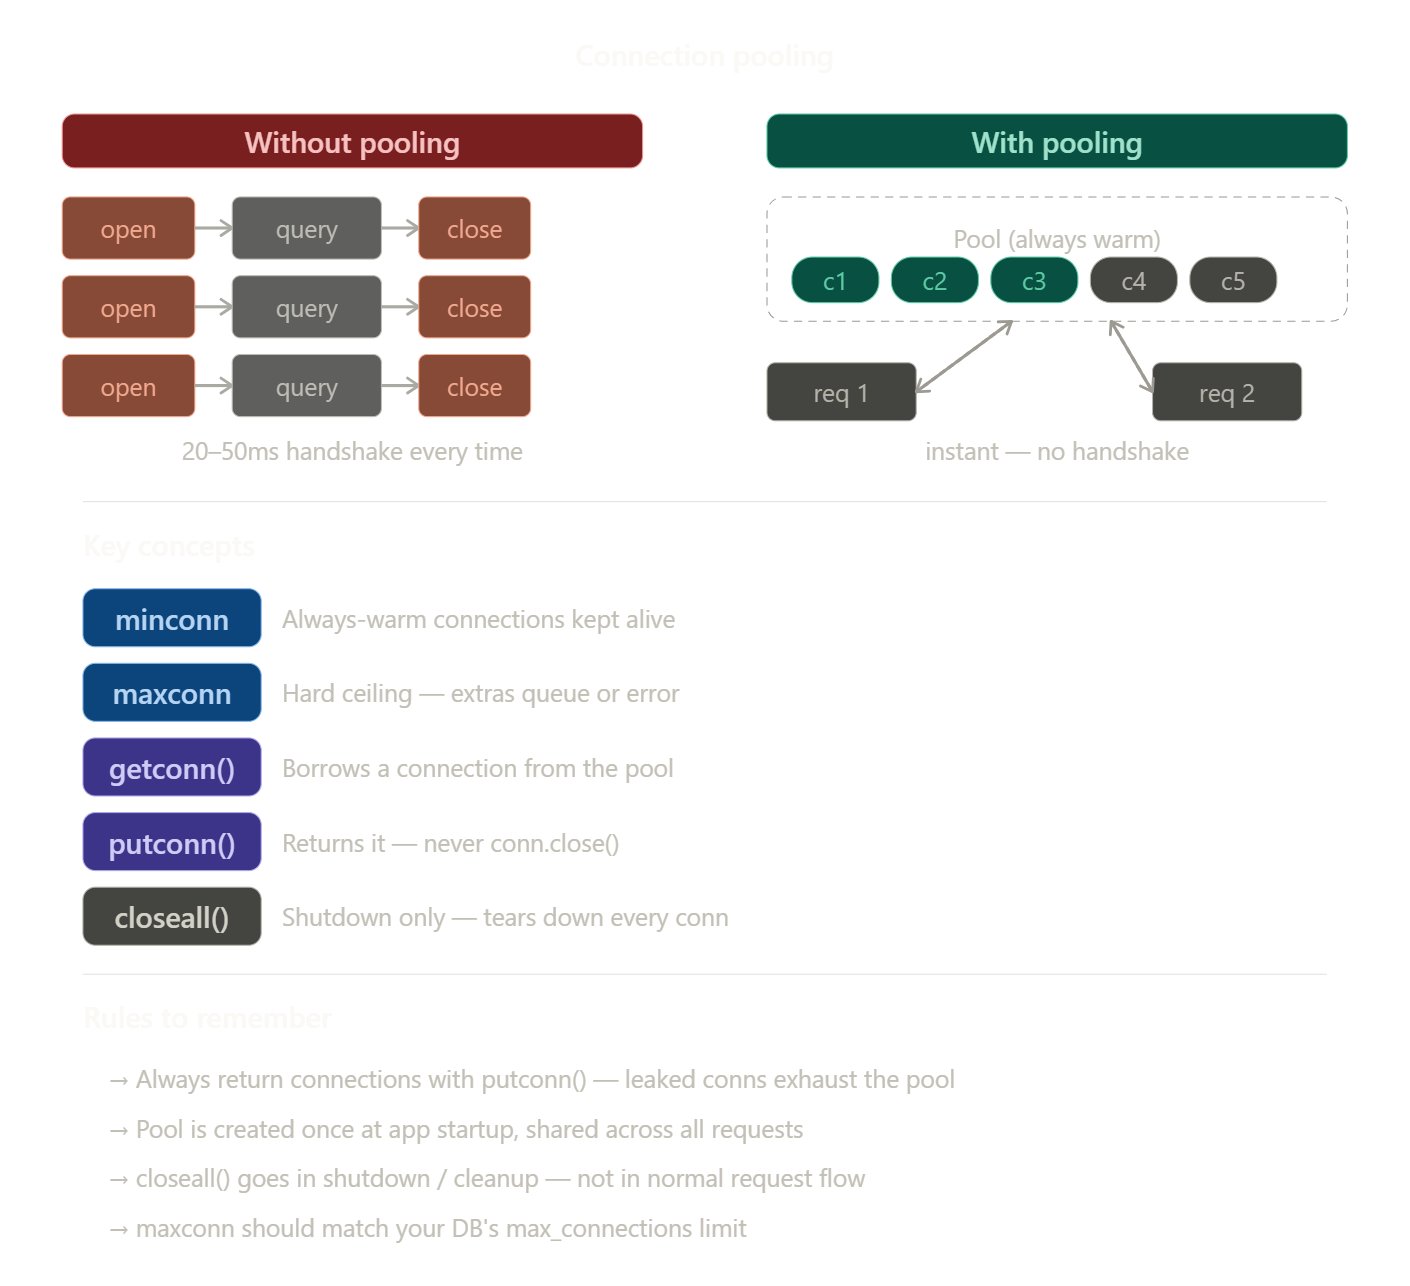

### Why to use connection pooling?
**ANSWER :** Simple, it makes things faster, increases performance.

# STORY OF CONNECTION POOLING:

Right now(before connection pooling) everytime a new request comes up or you call `get_connection()`, this process occurs:

  ```bash
    your code calls `get_connection()`
        ↓
    psycopg2 reaches PostgreSQL server
        ↓
    PostgreSQL authenticates you (checks user, password)
        ↓
    PostgreSQL allocates memory for your session
        ↓
    Returns a connection
        ↓
    you run query
        ↓
    conn.close() — all that setup gets thrown away
  ```

**That whole handshake takes time. Maybe 20-50ms. Fine for one user.**  
But as soon as number of requests increases, and everytime this handshake is happening, then the server starts to slows down.

**Connection pooling solves this.**
Instead of opening and closing connections, you maintain a pool of pre-opened connections sitting ready. Your code borrows one, uses it, returns it back to the pool.

<div style="border:1px solid #ccc; padding:12px; border-radius:8px;">

**Pool starts** → opens 5 connections and keeps them ready.

Request 1 comes in → borrows connection 2 → runs query → returns it  
Request 2 comes in → borrows connection 3 → runs query → returns it  
Request 3 comes in → borrows connection 2 again (already active in the pool)

No handshake. No authentication. Just instant.

</div>

**So after connection pooling:**
 - opening and closing connection everytime is avoided. 
 - this saves time and increases performance.

### Important concepts to understand from 'connection pooling':
**1. Minimum how many connections stay active in connection pool?**  
  - we define that in `minconn` field while creating connection pool.
  -  similarly maximum connections are defined in `maxconn` field.

**2. What if there are 1000 requests then how would connection pool handle these?**
  - Let's say connection has `maxconn = 10`. So *'Pool has 10 connections'*.   
    ```txt
    → 10 requests come in → each borrows one connection → so pool is full
    → Request #11 comes in → no connection available → it WAITS
    → Request #3 finishes → releases its connection back
    → Request #11 immediately gets that connection
    ```
  - **This works fine in practice because:**
    ```txt
    → A typical DB query takes ~5ms
    → So in 1 second, one connection can serve 200 requests
    → 10 connections = 2000 requests/second capacity
    ```

**3. But what if the queue gets too long?**
  - If requests pile up faster than they're served, two things can happen depending on your setup:
    - They wait too long → request times out → user sees an error
    - Pool raises an exception → PoolError: connection pool exhausted
  - This is when you increase `maxconn` — ***'but you can't just set it to 1000'***, because PostgreSQL itself has a connection limit (default 100). Every connection to Postgres costs it memory (~5–10MB each). 1000 open connections = Postgres using 5–10GB just for connections, nothing left for actual queries on the server.

### NOTE: *DO NOT FORGET TO RELEASE YOUR CONNECTION AFTER USE*
   ```py
    @app.route("/alerts")
    def get_alerts():
        conn = get_connection()
        data = fetch_alerts(conn)
        # ❌ forgot release_connection(conn) — connection is leaked
        return jsonify(data)
   ```  
Every request leaks one connection. After 10 requests, your pool of 10 is exhausted. The 11th request hangs forever waiting for one to free up.   

**The safe pattern is a `try/finally`:**
   ```py
    @app.route("/alerts")
    def get_alerts():
        conn = get_connection()
        try:
            data = fetch_alerts(conn)
            return jsonify(data)
        finally:
            release_connection(conn)  # ✅ runs even if an exception is thrown
   ```

**NOTE:** `finally` guarantees the connection goes back even if your code crashes midway.

## How to implment connection pool:

In [6]:
import psycopg2
from psycopg2 import pool
from psycopg2.extras import RealDictCursor

from config import DB_HOST, DB_PORT, DB_NAME, DB_USER, DB_PASSWORD

connection_pool = pool.SimpleConnectionPool(
    minconn=2,
    maxconn=10,
    # only abve 2 things are different, rest are same.
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD
)

def get_connection():
    return connection_pool.getconn()

def release_connection(conn):
    connection_pool.putconn(conn)

def close_all_connections():
    connection_pool.closeall()


if __name__ == "__main__":
    conn = get_connection()        # borrow from pool
    create_tables(conn)

    add_incident(conn, "Worker without helmet", "Zone-A", "high")
    add_incident(conn, "Spill near conveyor", "Zone-B", "medium")

    print("\n--- all incidents ---")
    for inc in get_all_incidents(conn):
        print(inc)

    release_connection(conn)       # return to pool, not close
    close_all_connections()        # only at app shutdown

table created    
incident saved: {'id': 4, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': datetime.datetime(2026, 3, 19, 13, 23, 47, 516292)}
incident saved: {'id': 5, 'title': 'Spill near conveyor', 'zone': 'Zone-B', 'severity': 'medium', 'created_at': datetime.datetime(2026, 3, 19, 13, 23, 47, 532774)}

--- all incidents ---
{'id': 5, 'title': 'Spill near conveyor', 'zone': 'Zone-B', 'severity': 'medium', 'created_at': datetime.datetime(2026, 3, 19, 13, 23, 47, 532774)}
{'id': 4, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'high', 'created_at': datetime.datetime(2026, 3, 19, 13, 23, 47, 516292)}
{'id': 3, 'title': 'Fire exit blocked', 'zone': 'Zone-C', 'severity': 'low', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 935876)}
{'id': 1, 'title': 'Worker without helmet', 'zone': 'Zone-A', 'severity': 'low', 'created_at': datetime.datetime(2026, 3, 18, 22, 41, 50, 928642)}


![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

## Using `context manager` we don't have to worry about releasing connection